# Feature Importance Testing
1. Feature importance is first calculated using the Random Forest Classifier.  
    1.1. Radom Forest is trained on the training data (ib)   
    1.2. Feature importance is calculated using the trained model but with the test data (oob)  
    1.3.  Another Random Forest is trained on the permuted training data (ib), which constitutes the null hypothesis.  
    1.4. Feature importance is calculated using the trained model but with the test data (oob)  
2. p-values are calculated for each feature using the permutation method.   
    2.1. The p-value is calculated as the proportion of times the permuted feature importance is greater than the original feature importance.   


In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os
from collections import defaultdict
# copy the model
from copy import deepcopy

# supress the warning
import warnings
warnings.filterwarnings("ignore")

In [8]:
# load the Wise dataset
wise = pd.read_csv('./wise.matrix')
display(wise.head())
# print(wise.shape)
wise_y = wise['Cancer Status']
wise_X = wise.drop(columns = ['Cancer Status', 'Sample', 'Tumor type', 'Stage'])
# display(wise_X.head())
print(wise_X.shape)

,Sample,Cancer Status,Stage,Tumor type,1:1-10000000,1:10000001-20000000,1:20000001-30000000,1:30000001-40000000,1:40000001-50000000,1:50000001-60000000,...,21:10000001-20000000,21:20000001-30000000,21:30000001-40000000,21:40000001-50000000,22:1-10000000,22:10000001-20000000,22:20000001-30000000,22:30000001-40000000,22:40000001-50000000,22:50000001-60000000
0,S0035.INDI_998_PLS_1,1,IV,Ovary,0.107617,-0.089664,0.088308,0.161890,0.195141,0.059390,...,-1.072653,-0.931427,-0.835283,-0.817325,0.0,-1.819371,-1.749369,-1.684808,-1.647312,-1.532646
1,S0035.INDI_983_PLS_1,1,IV,Ovary,-0.772378,-1.087627,-0.949005,0.489450,-0.670958,-0.221170,...,-0.897900,-0.524623,-0.922448,-0.793396,0.0,-0.675361,-0.943580,-0.758821,-0.932769,-0.749762
2,S0035.INDI_510_PLS_1A,1,IV,Ovary,-1.519912,-1.795528,-1.847208,0.015104,0.541656,0.411293,...,-0.796892,0.147432,-0.221206,-0.270937,0.0,-3.158424,-1.795942,-1.927368,-1.657170,-1.819905
3,S0063.INDIA_3343_PLS_1,1,IIIA,Lung,3.058270,2.851708,2.665363,-0.828755,-0.752899,-0.695762,...,-1.603144,-1.409415,-0.781825,-0.207052,0.0,2.169607,1.920353,-0.745165,-0.920590,-0.716167
4,S0064.INDIA_3360_PLS_1,1,IIB,Lung,0.017034,0.189540,-0.901394,-0.537247,-0.986964,-0.564267,...,0.044192,0.188299,0.263522,1.150110,0.0,-0.045028,-0.220047,0.243085,1.025034,1.885327


(704, 300)


In [9]:
# Wise
wise_all = pd.read_csv('./wise_All.matrix')
display(wise_all.head())
print(wise_all.shape)
# drop nan rows
# wise_all = wise_all.dropna()
wise_all_y = wise_all['Cancer Status']
# map the cancer status to 0 and 1
wise_all_y = wise_all_y.map({'Healthy':0, 'Cancer':1})
wise_all_X = wise_all.drop(columns = ['Run','Library','Cancer Status', 'Sample', 'Tumor type', 'Stage'])
display(wise_all_X.head(10))
print(wise_all_X.shape)

,Run,Sample,Library,Cancer Status,Stage,Tumor type,1:1-10000000,1:10000001-20000000,1:20000001-30000000,1:30000001-40000000,...,21:10000001-20000000,21:20000001-30000000,21:30000001-40000000,21:40000001-50000000,22:1-10000000,22:10000001-20000000,22:20000001-30000000,22:30000001-40000000,22:40000001-50000000,22:50000001-60000000
0,S0028,INDI_918_PLS_1A,A387-12,Cancer,IV,Stomach,0.468038,-3.145530,-1.712623,-0.735046,...,-1.135428,0.910290,-0.814004,0.465840,NaN,-2.455095,0.242265,-0.999295,0.586578,4.020335
1,S0028,INDI_980_PLS_1,A387-13,Cancer,IV,Stomach,0.632628,-3.349720,-0.246645,-0.336667,...,-0.728640,0.982447,-1.233654,1.355670,NaN,2.373436,4.932168,-0.335874,0.462123,2.862172
2,S0034,INDI_580_PLS_1A,A396-13,Cancer,IV,Colorectal,-2.123124,-2.840198,-2.896575,-2.638872,...,0.540503,-0.127143,-0.174641,0.031823,NaN,0.298749,-0.050700,-0.240639,0.109563,0.532129
3,S0034,INDI_730_PLS_1A,A396-04,Cancer,IV,Pancreas,-1.318004,-1.953182,-1.099582,-0.309286,...,0.567452,-0.766169,-0.743883,1.192330,NaN,-2.766405,0.101859,-1.526696,0.981383,-1.887319
4,S0034,INDI_481_PLS_1A,A396-10,Cancer,IV,Liver,0.199915,-1.960120,-1.531292,-0.322800,...,-2.222321,0.856329,-0.179628,-0.078619,NaN,-7.305575,-3.274674,-1.136304,-0.444130,0.926091


(1991, 306)


,1:1-10000000,1:10000001-20000000,1:20000001-30000000,1:30000001-40000000,1:40000001-50000000,1:50000001-60000000,1:60000001-70000000,1:70000001-80000000,1:80000001-90000000,1:90000001-100000000,...,21:10000001-20000000,21:20000001-30000000,21:30000001-40000000,21:40000001-50000000,22:1-10000000,22:10000001-20000000,22:20000001-30000000,22:30000001-40000000,22:40000001-50000000,22:50000001-60000000
0,0.468038,-3.145530,-1.712623,-0.735046,-0.596196,-0.984366,-0.614533,1.040431,0.854524,-0.618427,...,-1.135428,0.910290,-0.814004,0.465840,NaN,-2.455095,0.242265,-0.999295,0.586578,4.020335
1,0.632628,-3.349720,-0.246645,-0.336667,-0.261915,-0.313818,-0.506784,0.677787,0.877207,0.171904,...,-0.728640,0.982447,-1.233654,1.355670,NaN,2.373436,4.932168,-0.335874,0.462123,2.862172
2,-2.123124,-2.840198,-2.896575,-2.638872,-2.749420,-2.938617,-3.073245,-2.771971,-2.790879,-3.014190,...,0.540503,-0.127143,-0.174641,0.031823,NaN,0.298749,-0.050700,-0.240639,0.109563,0.532129
3,-1.318004,-1.953182,-1.099582,-0.309286,0.307930,-0.018172,-1.846236,1.093738,0.154590,-0.731298,...,0.567452,-0.766169,-0.743883,1.192330,NaN,-2.766405,0.101859,-1.526696,0.981383,-1.887319
4,0.199915,-1.960120,-1.531292,-0.322800,-1.294747,-2.039103,-2.074370,0.719124,-0.084680,-1.684656,...,-2.222321,0.856329,-0.179628,-0.078619,NaN,-7.305575,-3.274674,-1.136304,-0.444130,0.926091
5,-0.422501,-1.176739,-0.697730,-1.186666,-0.993333,-1.164834,-1.859197,0.043965,0.035079,-1.413566,...,-0.001860,0.271307,-0.340216,0.267407,NaN,0.056550,-1.119487,-0.573910,-0.036823,2.541237
6,-1.540736,-0.744457,0.743682,-0.083271,0.556707,0.127913,0.442714,0.580879,0.292343,-1.039185,...,-2.651988,0.216153,0.355764,1.720476,NaN,-5.747655,-2.281148,0.995363,-1.024352,-1.618191
7,0.107617,-0.089664,0.088308,0.161890,0.195141,0.059390,-0.047255,0.280065,0.129975,0.490819,...,-1.072653,-0.931427,-0.835283,-0.817325,NaN,-1.819371,-1.749369,-1.684808,-1.647312,-1.532646
8,-0.772378,-1.087627,-0.949005,0.489450,-0.670958,-0.221170,-1.017481,-0.763074,-1.123401,-1.173831,...,-0.897900,-0.524623,-0.922448,-0.793396,NaN,-0.675361,-0.943580,-0.758821,-0.932769,-0.749762
9,-1.792493,-1.873985,-1.624426,-0.908653,-1.056033,-1.400742,-2.057480,-1.632745,-1.389339,-1.619607,...,-2.676097,-1.865423,-0.871783,-0.392756,NaN,0.162990,0.307872,-0.712815,-0.793441,-0.515901


(1991, 300)


In [10]:
# remove the columns with all nan values
nan_cols = wise_all_X.isnull().all(axis=0).to_numpy()
print("number of columns with all nan values: ", np.sum(nan_cols))
# get the index of the columns with all nan values
nan_cols_idx = np.where(nan_cols)[0]
print(nan_cols_idx)
wise_all_X = wise_all_X.loc[:, ~nan_cols]
print(wise_all_X.shape)
wise_all_X.isnull().any(axis=1).sum()

number of columns with all nan values:  16
[ 12  13  89 114 162 163 164 215 227 228 238 239 252 258 289 294]
(1991, 284)


1963

In [2]:
# Functions to calculate the feature importance p-values
from sklearn.ensemble import RandomForestClassifier
from joblib import Parallel, delayed
from scipy.stats import false_discovery_control
from statsmodels.stats.multitest import multipletests

def statistics(feature_importance, idx, n_estimators=1000):
    r"""
    Helper function that calulates the feature importance
    test statistic.
    """
    stat = np.zeros(len(feature_importance[0]))
    for ii in range(n_estimators):
        r = ss.rankdata(1-feature_importance[idx[ii]], method="max")
        r_0 = ss.rankdata(1-feature_importance[idx[n_estimators + ii]], method="max")
        stat += (r_0 > r) * 1
    stat /= n_estimators
    return stat


def perm_stat(feature_importance, n_estimators=1000):
    r"""
    Helper function that calulates the null distribution.
    """
    idx = list(range(2 * n_estimators))
    # print(idx)
    np.random.shuffle(idx)
    # print(idx)
    return statistics(feature_importance, idx, n_estimators=n_estimators)


def test(feature_importance, n_repeats=1000, n_jobs=-1, n_estimators=1000):
    r"""
    Calculates p values for fearture imprtance test.
    Parameters
    ----------
    X : ArrayLike of shape (n_samples, n_features)
        The data matrix.
    y : ArrayLike of shape (n_samples, n_outputs)
        The target matrix.
    n_repeats : int, optional
        Number of times to sample the null distribution, by default 1000.
    n_jobs : int, optional
        Number of workers to use, by default 1000.
    Returns
    -------
    stat : float
        The computed discriminability statistic.
    pvalue : float
        The computed one sample test p-value.
    """
    stat = statistics(feature_importance, list(range(2 * n_estimators)), n_estimators=n_estimators)
    # print(stat)
    null_stat = Parallel(n_jobs=n_jobs)(
        delayed(perm_stat)(feature_importance, n_estimators=n_estimators)
        for _ in range(n_repeats)
    )
    count = np.sum((null_stat >= stat) * 1, axis=0)
    p_val = (1 + count) / (1 + n_repeats)
    # adjust p-value for multiple testing using Bonferroni-Holm correction
    # rank the p-values
    ranks = ss.rankdata(p_val)
    p_val_adusted = p_val * (len(p_val) - ranks + 1)
    p_val_adusted = p_val_adusted #/ np.max(p_val_adusted) # normalize the p-values. This is arbitrary
    return stat, p_val, p_val_adusted

In [13]:
# set the parameters
dataset = 'wise'
n_estimators = 10000
split = (0.5, 0.5)
n_repeats = 10000
n_jobs = -5
max_features = 1/3
# =================================================================================================
if dataset == 'wise':
    X = wise_X
    y = wise_y
# if dataset == 'wise_all':
#     X = wise_all_X
#     y = wise_all_y
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split[1], random_state=None)
# # train using 
# model = RandomForestClassifier(n_estimators=n_estimators, n_jobs=n_jobs)
# model.fit(X_train,y_train)
# # test the model on the test data
# y_pred = model.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred)
# print(accuracy)

# # feature_importance_origin = model.feature_importances_
# # feature_importance per tree is a array of size n_features, so you get a list of n_estimators arrays
# feature_importance_origin = [tree.feature_importances_ for tree in model.estimators_]
# # print(len(feature_importance_origin[0]))
# permuted_model = RandomForestClassifier(n_estimators=n_estimators, n_jobs=n_jobs)
# y_cp = y_train.copy()
# # shuffle the labels
# y_cp = np.random.permutation(y_cp)
# # np.random.shuffle(y_cp)
# permuted_model.fit(X_train,y_cp)
# permuted_feature_importance = [tree.feature_importances_ for tree in permuted_model.estimators_]
# # del permuted_model
# feature_importance = np.concatenate((feature_importance_origin, permuted_feature_importance))
# # print(len(feature_importance))
# stat, p_val_ib_, p_val_ib_adjusted = test(feature_importance,
#             n_repeats = n_repeats,
#             n_jobs = n_jobs,
#             n_estimators = n_estimators)
# # get the feature importance from the model
# mean_feature_importance_ib = model.feature_importances_
# # create a dataframe to store the p-values and the feature importance
# p_val_ib = pd.DataFrame({'feature':X_train.columns, 'p_value_ib':p_val_ib_, 'p_value_ib_adjusted':p_val_ib_adjusted, 'feature_importance_ib':mean_feature_importance_ib})
# display(p_val_ib)

In [7]:
# p_val_ib.sort_values(by='feature_importance_ib', ascending=False)[:20]

# Apply the held-out set and get the feature 
## Feature Importance using oob samples

In [3]:
# define the function to calculate the feature importance using the oob samples
def get_oob_feature_importance(model, X_test, y_test, X_train=None, y_train=None, n_estimators=1000, n_jobs=10, return_model=False, max_features=None):
    r"""
    Calculate the feature importance using the oob samples. The feature importance is calculated by
    calcurating the gini impurity for each node in each tree in the random forest model. Here we use the oob samples
    to calculate the gini impurity instead of the training samples.

    Parameters
    ----------
    model : RandomForestClassifier
        The trained random forest model.
    X_test : ArrayLike of shape (n_samples, n_features)
        The test data matrix.
    y_test : ArrayLike of shape (n_samples, n_outputs)
        The test target matrix.
    X_train : ArrayLike of shape (n_samples, n_features), optional
        The training data matrix, by default None.
    y_train : ArrayLike of shape (n_samples, n_outputs), optional
        The training target matrix, by default None.
    Returns
    -------
    ArrayLike of shape (n_features,)
        The feature importance.
    """
    # 0. Check if the model is trained
    if not hasattr(model, 'estimators_'):
        if X_train is None or y_train is None:
            raise ValueError("The model is not trained. Please provide the training data.")
        else:
             # 1. train a random forest model using X_train, y_train (if X_train and y_train are provided)
            model = RandomForestClassifier(n_estimators=n_estimators, n_jobs=n_jobs, max_features=max_features)
            model.fit(X_train, y_train)
    # 2. copy the model
    model_cp = deepcopy(model)
    # 3. for each tree in the model do the following
    for i, tree in enumerate(model.estimators_):
        # 3.1. copy the tree
        tree_cp = deepcopy(tree)
        # 3.2. collect all the samples at each node
        tree_nodes = defaultdict(list)
        node_indicator = tree.decision_path(X_test)
        leave_id = tree.apply(X_test)
        for sample_id in range(X_test.shape[0]):
            node_index = node_indicator.indices[node_indicator.indptr[sample_id]: node_indicator.indptr[sample_id + 1]]
            # check if the nodes in the node_indicator are the same as the nodes in the tree
            assert np.array_equal(len(tree.tree_.impurity), tree.tree_.node_count)
            for node in node_index:
                tree_nodes[node].append(sample_id)
        # 3.3. calcurate the gini impurity for each node
        for node in range(tree.tree_.node_count):
            node = int(node)
            sample_ids = tree_nodes[node]
            if len(sample_ids) == 0:
                tree_cp.tree_.impurity[node] = 0
            tree_cp.tree_.impurity[node] = 1 - np.sum(np.square(np.bincount(np.array(y_test)[sample_ids]) / len(sample_ids)))
        # compute the feature importance
        tree_cp.tree_.compute_feature_importances(normalize=False)
        # 3.4. replace the tree in the copied model with the new tree
        model_cp.estimators_[i] = tree_cp
    # 4. normalize the feature importance of the copied model
    oob_sample_feature_importance = [tree.feature_importances_ for tree in model_cp.estimators_]
    if return_model:
        return oob_sample_feature_importance, model_cp
    else:
        return oob_sample_feature_importance

In [4]:
# define the function to calculate in-bag and out-of-bag feature importance
def get_oob_feature_importances(model, X_train, y_train, X_test, y_test, n_estimators=1000, n_jobs=10, return_model=False, max_features=None):
    r"""
    Calculate the in-bag and out-of-bag feature importance of the random forest model.

    Parameters
    ----------
    model : RandomForestClassifier
        The trained random forest model.
    X_train : ArrayLike of shape (n_samples, n_features)
        The training data matrix.
    y_train : ArrayLike of shape (n_samples, n_outputs)
        The training target matrix.
    X_test : ArrayLike of shape (n_samples, n_features)
        The test data matrix.
    y_test : ArrayLike of shape (n_samples, n_outputs)
        The test target matrix.
    n_estimators : int, optional
        The number of trees in the random forest model, by default 1000.
    n_jobs : int, optional
        The number of workers to use, by default 10.
    Returns
    -------
    ArrayLike of shape (n_features,)
        The in-bag feature importance.
    ArrayLike of shape (n_features,)
        The out-of-bag feature importance.
    """
    # 1. train a random forest model using X_train, y_train
    model.fit(X_train, y_train)
    # 2. get the out-of-bag feature importance
    oob_sample_feature_importance = get_oob_feature_importance(model, X_test, y_test, X_train, y_train, n_estimators=n_estimators, n_jobs=n_jobs)
    # 3. get the in-bag feature importance
    in_bag_sample_feature_importance = [tree.feature_importances_ for tree in model.estimators_]

    return in_bag_sample_feature_importance, oob_sample_feature_importance, model

In [5]:
# define a function to do all above to get the features importance p-values from a dataset
def get_feature_importance_p_values(X, y, n_estimators=1000, n_repeats=1000, n_jobs=-1, max_features=1/3, split=(0.5, 0.5)):
    r"""
    Calculate the feature importance p-values using the in-bag and out-of-bag samples.

    Parameters
    ----------
    X : ArrayLike of shape (n_samples, n_features)
        The data matrix.
    y : ArrayLike of shape (n_samples, n_outputs)
        The target matrix.
    n_estimators : int, optional
        The number of trees in the random forest model, by default 1000.
    n_repeats : int, optional
        Number of times to sample the null distribution, by default 1000.
    n_jobs : int, optional
        Number of workers to use, by default -1.
    max_features : str, optional
        The number of features to consider when looking for the best split, by default 'sqrt'.
    split : tuple, optional
        The split ratio of the data into training and testing sets, by default (0.5, 0.5).
    Returns
    -------
    DataFrame
        The feature importance p-values.
    """
    # check input
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    # get the mean of each column
    X_mean = np.mean(X, axis=0)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    # cast y to int64
    y = y.astype("int64")
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split[1], random_state=None
    )
    # get the in-bag and out-of-bag feature importance
    model = RandomForestClassifier(
        n_estimators=n_estimators, n_jobs=n_jobs, max_features=max_features
    )
    in_bag_sample_feature_importance, oob_sample_feature_importance, trained_model = (
        get_oob_feature_importances(
            model,
            X_train,
            y_train,
            X_test,
            y_test,
            n_estimators=n_estimators,
            n_jobs=n_jobs,
            max_features=max_features,
        )
    )
    if trained_model is not None:
        # get the predictions and calculate the accuracy
        y_pred = trained_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print("The accuracy of the model is: ", accuracy)
    # get the permuted feature importance
    permuted_model = RandomForestClassifier(
        n_estimators=n_estimators, n_jobs=n_jobs, max_features=max_features
    )
    y_train_permuted = y_train.copy()
    # shuffle the labels
    y_train_permuted = np.random.permutation(y_train_permuted)
    # get the in-bag and out-of-bag feature importance
    (
        in_bag_sample_feature_importance_permuted,
        oob_sample_feature_importance_permuted,
        trained_model_permuted,
    ) = get_oob_feature_importances(
        permuted_model,
        X_train,
        y_train_permuted,
        X_test,
        y_test,
        n_estimators=n_estimators,
        n_jobs=n_jobs,
        max_features=max_features,
    )
    if trained_model_permuted is not None:
        # get the predictions and calculate the accuracy
        y_pred_permuted = trained_model_permuted.predict(X_test)
        accuracy_permuted = accuracy_score(y_test, y_pred_permuted)
        print("The accuracy of the model with permuted labels is: ", accuracy_permuted)
    # calcurate p-value for the feature importance with the oob samples
    feature_importance_test_oob = np.concatenate(
        (oob_sample_feature_importance, oob_sample_feature_importance_permuted)
    )
    # print(len(feature_importance))
    stat_oob, p_val_oob_, p_val_oob_adjusted = test(
        feature_importance_test_oob,
        n_repeats=n_repeats,
        n_jobs=n_jobs,
        n_estimators=n_estimators,
    )
    # calcurate p-value for the feature importance with the in-bag samples
    feature_importance_test_ib = np.concatenate(
        (in_bag_sample_feature_importance, in_bag_sample_feature_importance_permuted)
    )
    # print(len(feature_importance))
    stat_ib, p_val_ib_, p_val_ib_adjusted = test(
        feature_importance_test_ib,
        n_repeats=n_repeats,
        n_jobs=n_jobs,
        n_estimators=n_estimators,
    )
    # get the mean feature importance
    mean_feature_importance_oob = np.mean(oob_sample_feature_importance, axis=0)
    mean_feature_importance_oob_permuted = np.mean(oob_sample_feature_importance_permuted, axis=0)
    mean_feature_importance_ib = np.mean(in_bag_sample_feature_importance, axis=0)
    mean_feature_importance_ib_permuted = np.mean(in_bag_sample_feature_importance_permuted, axis=0)
    # create a dataframe to store the p-values and the feature importance
    feature = X_train.columns if isinstance(X_train, pd.DataFrame) else np.arange(X_train.shape[1])
    p_val_ib = pd.DataFrame({'feature':feature, 'p_value_ib':p_val_ib_, 'p_value_ib_adjusted':p_val_ib_adjusted, 'feature_importance_ib':mean_feature_importance_ib, 'feature_importance_ib_permuted':mean_feature_importance_ib_permuted})
    p_val_oob = pd.DataFrame({'feature':feature, 'p_value_oob':p_val_oob_, 'p_value_oob_adjusted':p_val_oob_adjusted, 'feature_importance_oob':mean_feature_importance_oob, 'feature_importance_oob_permuted':mean_feature_importance_oob_permuted})
    # join the two dataframes
    p_val_oob = p_val_oob.set_index('feature')
    p_val_ib = p_val_ib.set_index('feature')
    feature_importance_p_val = p_val_ib.join(p_val_oob, how = 'inner', on='feature')
    # add the parameters to the dataframe
    feature_importance_p_val['accuracy'] = accuracy
    feature_importance_p_val['accuracy_permuted'] = accuracy_permuted
    # make the index as a column
    feature_importance_p_val.reset_index(inplace=True)
    return feature_importance_p_val

In [7]:
# set the parameters
n_estimators = 100
split = (0.5, 0.5)
n_repeats = 1000
n_jobs = -5
max_features = 0.3
# =================================================================================================
# X = wise_X
# y = wise_y
# X = wise_all_X
# y = wise_all_y
# feature_importance_p_val = get_feature_importance_p_values(X, y, n_estimators=n_estimators, n_repeats=n_repeats, n_jobs=n_jobs, max_features=max_features, split=split)

In [13]:
# # get the in-bag and out-of-bag feature importance
# model = RandomForestClassifier(n_estimators=n_estimators, n_jobs=n_jobs, max_features=max_features)
# in_bag_sample_feature_importance, oob_sample_feature_importance, _ = get_oob_feature_importances(model, X_train, y_train, X_test, y_test, n_estimators=n_estimators, n_jobs=n_jobs, max_features=max_features, return_model=False)

In [14]:
# # get the permuted feature importance
# permuted_model = RandomForestClassifier(n_estimators=n_estimators, n_jobs=n_jobs, max_features=max_features)
# y_train_permuted = y_train.copy()
# # shuffle the labels
# y_train_permuted = np.random.permutation(y_train_permuted)
# # get the in-bag and out-of-bag feature importance
# in_bag_sample_feature_importance_permuted, oob_sample_feature_importance_permuted, _ = get_oob_feature_importances(permuted_model, X_train, y_train_permuted, X_test, y_test, n_estimators=n_estimators, n_jobs=n_jobs, max_features=max_features, return_model=False)

In [15]:
# # calcurate p-value for the feature importance with the oob samples
# feature_importance_test_oob = np.concatenate((oob_sample_feature_importance, oob_sample_feature_importance_permuted))
# # print(len(feature_importance))
# stat_oob, p_val_oob_, p_val_oob_adjusted = test(feature_importance_test_oob,
#             n_repeats = n_repeats,
#             n_jobs = n_jobs,
#             n_estimators = n_estimators)

In [16]:
# # calcurate p-value for the feature importance with the in-bag samples
# feature_importance_test_ib = np.concatenate((in_bag_sample_feature_importance, in_bag_sample_feature_importance_permuted))
# # print(len(feature_importance))
# stat_ib, p_val_ib_, p_val_ib_adjusted = test(feature_importance_test_ib,
#             n_repeats = n_repeats,
#             n_jobs = n_jobs,
#             n_estimators = n_estimators)

In [17]:

# mean_feature_importance_ib = np.mean(in_bag_sample_feature_importance, axis=0)
# mean_feature_importance_ib_permuted = np.mean(in_bag_sample_feature_importance_permuted, axis=0)
# p_val_ib = pd.DataFrame({'feature':X_train.columns, 'p_value_ib':p_val_ib_, 'p_value_ib_adjusted':p_val_ib_adjusted, 'feature_importance_ib':mean_feature_importance_ib, 'feature_importance_ib_permuted':mean_feature_importance_ib_permuted})
# # p_val_ib.sort_values(by='p_value_ib_adjusted', ascending=True).head(20)
# mean_feature_importance_oob = np.mean(oob_sample_feature_importance, axis=0)
# mean_feature_importance_oob_permuted = np.mean(oob_sample_feature_importance_permuted, axis=0)
# p_val_oob = pd.DataFrame({'feature':X_train.columns, 'p_value_oob':p_val_oob_, 'p_value_oob_adjusted':p_val_oob_adjusted, 'feature_importance_oob':mean_feature_importance_oob, 'feature_importance_oob_permuted':mean_feature_importance_oob_permuted})
# # p_val_oob = p_val_oob.set_index('feature')
# # display(p_val_oob.head(10))
# # p_val_oob.sort_values(by='p_value_oob_adjusted', ascending=True).head(20)
# # Run this only once
# # join the two dataframes
# p_val_oob = p_val_oob.set_index('feature')
# p_val_ib = p_val_ib.set_index('feature')
# feature_importance_p_val = p_val_ib.join(p_val_oob, how = 'inner', on='feature')
# print(feature_importance_p_val.shape)
# # make the index as a column
# feature_importance_p_val.reset_index(inplace=True)
# feature_importance_p_val

In [18]:
# feature_importance_p_val.sort_values(by='p_value_oob_adjusted', ascending=True).head(20)

,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted
156,8:130000001-140000000,0.000100,0.029297,0.215672,0.003566,0.0001,0.029997,0.267423,0.002549
0,1:1-10000000,0.999200,208.333217,0.000422,0.001480,1.0000,150.000000,-0.000148,-0.000042
203,12:20000001-30000000,1.000000,94.000000,0.001050,0.003755,1.0000,150.000000,0.000183,0.007221
202,12:10000001-20000000,1.000000,94.000000,0.000401,0.005287,1.0000,150.000000,0.000203,0.008141
201,12:1-10000000,1.000000,94.000000,0.000191,0.003662,1.0000,150.000000,0.000084,0.011681
200,11:130000001-140000000,1.000000,94.000000,0.000747,0.012722,1.0000,150.000000,0.000197,0.000011
199,11:120000001-130000000,1.000000,94.000000,0.000239,0.002864,1.0000,150.000000,0.000005,0.001474
198,11:110000001-120000000,1.000000,94.000000,0.000428,0.002928,1.0000,150.000000,0.000059,0.001685
197,11:100000001-110000000,1.000000,94.000000,0.000191,0.002319,1.0000,150.000000,0.000034,0.001557
196,11:90000001-100000000,0.999900,191.480852,0.000340,0.001850,1.0000,150.000000,0.000019,-0.000363


In [19]:
# feature_importance_p_val.sort_values(by='feature_importance_oob', ascending=False).head(20)

,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted
156,8:130000001-140000000,0.000100,0.029297,0.215672,0.003566,0.0001,0.029997,0.267423,0.002549
157,8:140000001-150000000,0.000100,0.029297,0.102565,0.001962,1.0000,150.000000,0.120555,0.004296
154,8:110000001-120000000,0.002600,0.735726,0.061641,0.004328,1.0000,150.000000,0.075153,-0.004381
155,8:120000001-130000000,0.000100,0.029297,0.070766,0.002179,1.0000,150.000000,0.074708,0.001150
152,8:90000001-100000000,0.000100,0.029297,0.035808,0.002686,1.0000,150.000000,0.049733,0.014525
150,8:70000001-80000000,0.033997,9.485051,0.034918,0.007152,1.0000,150.000000,0.044431,0.040762
21,1:210000001-220000000,0.000100,0.029297,0.020225,0.002014,1.0000,150.000000,0.034203,0.007137
287,20:50000001-60000000,0.000100,0.029297,0.021398,0.002647,1.0000,150.000000,0.031600,0.009360
15,1:150000001-160000000,0.000100,0.029297,0.025576,0.002704,1.0000,150.000000,0.027111,0.001380
17,1:170000001-180000000,0.000100,0.029297,0.012420,0.001137,1.0000,150.000000,0.022094,0.002232


# With Trunk data 

In [8]:

def _moving_avg_cov(n_dim, rho):
    # Create a meshgrid of indices
    i, j = np.meshgrid(np.arange(1, n_dim + 1), np.arange(1, n_dim + 1), indexing="ij")

    # Calculate the covariance matrix using the corrected formula
    cov_matrix = rho ** np.abs(i - j)

    # Apply the banding condition
    cov_matrix[abs(i - j) > 1] = 0
    return cov_matrix


def _autoregressive_cov(n_dim, rho):
    # Create a meshgrid of indices
    i, j = np.meshgrid(np.arange(1, n_dim + 1), np.arange(1, n_dim + 1), indexing="ij")

    # Calculate the covariance matrix using the corrected formula
    cov_matrix = rho ** np.abs(i - j)

    return cov_matrix

def make_trunk_classification(
    n_samples,
    n_dim=4096,
    n_informative=256,
    mu_0: int = 0,
    mu_1: int = 1,
    rho: int = 0,
    band_type: str = "ma",
    return_params: bool = False,
    scaling_factor: float = 1.0,
    seed=None,
):
    """Generate trunk binary classification dataset.

    For each dimension in the first distribution, there is a mean of :math:`1 / d`, where
    ``d`` is the dimensionality. The covariance is the identity matrix.
    The second distribution has a mean vector that is the negative of the first.
    As ``d`` increases, the two distributions become closer and closer.

    Full details for the trunk simulation can be found in :footcite:`trunk1982`.

    Instead of the identity covariance matrix, one can implement a banded covariance matrix
    that follows :footcite:`Bickel_2008`.

    Parameters
    ----------
    n_samples : int
        Number of sample to generate. Must be an even number, else the total number of samples generated will be ``n_samples - 1``.
    n_dim : int, optional
        The dimensionality of the dataset and the number of
        unique labels, by default 4096.
    n_informative : int, optional
        The informative dimensions. All others for ``n_dim - n_informative``
        are Gaussian noise. Default is 256.
    mu_0 : int, optional
        The mean of the first distribution. By default -1. The mean of the distribution will decrease
        by a factor of ``sqrt(i)`` for each dimension ``i``.
    mu_1 : int, optional
        The mean of the second distribution. By default 1. The mean of the distribution will decrease
        by a factor of ``sqrt(i)`` for each dimension ``i``.
    rho : float, optional
        The covariance value of the bands. By default 0 indicating, an identity matrix is used.
    band_type : str
        The band type to use. For details, see Example 1 and 2 in :footcite:`Bickel_2008`.
        Either 'ma', or 'ar'.
    return_params : bool, optional
        Whether or not to return the distribution parameters of the classes normal distributions.
    scaling_factor : float, optional
        The scaling factor for the covariance matrix. By default 1.
    seed : int, optional
        Random seed, by default None.

    Returns
    -------
    X : np.ndarray of shape (n_samples, n_dim), dtype=np.float64
        Trunk dataset as a dense array.
    y : np.ndarray of shape (n_samples,), dtype=np.intp
        Labels of the dataset.
    means : list of ArrayLike of shape (n_dim,), dtype=np.float64
        The mean vector for each class starting with class 0.
        Returned if ``return_params`` is True.
    covs : list of ArrayLike of shape (n_dim, n_dim), dtype=np.float64
        The covariance for each class. Returned if ``return_params`` is True.

    Notes
    -----
    **Trunk**: The trunk simulation decreases the signal-to-noise ratio as the dimensionality
    increases. This is implemented by decreasing the mean of the distribution by a factor of
    ``sqrt(i)`` for each dimension ``i``. Thus for instance if the means of distribution one
    and two are 1 and -1 respectively, the means for the first dimension will be 1 and -1,
    for the second dimension will be 1/sqrt(2) and -1/sqrt(2), and so on.

    **Trunk Overlap**: The trunk overlap simulation generates two classes of data with the same
    covariance matrix and mean vector of zeros.

    Covariance: The covariance matrix among different dimensions is controlled by the ``rho`` parameter
    and the ``band_type`` parameter. The ``band_type`` parameter controls the type of band to use, while
    the ``rho`` parameter controls the specific scaling factor for the covariance matrix while going
    from one dimension to the next.

    References
    ----------
    .. footbibliography::
    """
    if n_dim < n_informative:
        raise ValueError(
            f"Number of informative dimensions {n_informative} must be less than number "
            f"of dimensions, {n_dim}"
        )
    rng = np.random.default_rng(seed=seed)

    mu_1_vec = np.array([mu_1 / np.sqrt(i) for i in range(1, n_informative + 1)])
    mu_0_vec = np.array([mu_0 / np.sqrt(i) for i in range(1, n_informative + 1)])

    if rho != 0:
        if band_type == "ma":
            cov = _moving_avg_cov(n_informative, rho)
        elif band_type == "ar":
            cov = _autoregressive_cov(n_informative, rho)
        else:
            raise ValueError(f'Band type {band_type} must be one of "ma", or "ar".')
    else:
        cov = np.identity(n_informative)

    # allow arbitrary uniform scaling of the covariance matrix
    cov = scaling_factor * cov

    # speed up computations for large multivariate normal matrix with SVD approximation
    if n_informative > 1000:
        method = "cholesky"
    else:
        method = "svd"

    X = np.vstack(
        [
            rng_children.multivariate_normal(mu_vec, cov, n_samples // 2, method=method)
            for rng_children, mu_vec in zip(rng.spawn(2), [mu_0_vec, mu_1_vec])
        ]
    )

    if n_dim > n_informative:
        X = np.hstack(
            (
                X,
                np.hstack(
                    [
                        rng_children.normal(loc=0, scale=1, size=(X.shape[0], 1))
                        for rng_children in rng.spawn(n_dim - n_informative)
                    ]
                ),
            )
        )

    y = np.concatenate((np.zeros(n_samples // 2), np.ones(n_samples // 2)))

    if return_params:
        return [X, y, [mu_0_vec, mu_1_vec], [cov, cov]]
    return X, y

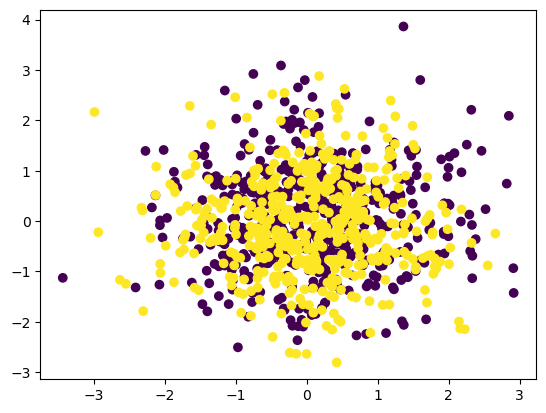

In [9]:
X, y = make_trunk_classification(n_samples=1000, n_dim=15, n_informative=5, mu_0=0, mu_1=1, rho=0, band_type='ma', return_params=False, scaling_factor=1.0, seed=None)
# plot X using y as the color
plt.scatter(X[:,9], X[:,8], c=y)

In [10]:
# pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.722840,0.901184,0.017907,0.560854,0.374123,-0.026449,0.435548,0.085561,0.508414,-0.485475,-0.113993,-0.627793,1.159144,-0.186324,-0.542038
1,1.436121,-0.472379,0.945367,-2.451966,-2.407707,-0.821887,-0.807562,-1.693772,0.982382,-0.553678,0.730448,0.048604,0.040735,-1.254522,0.869303
2,1.100318,0.531769,0.061948,-0.320312,-1.080140,-1.213876,-1.018250,-1.588421,-0.357119,-0.901192,0.341172,1.496172,-0.981360,0.162117,0.619029
3,0.531313,0.262879,-2.718184,1.368823,-1.913698,-1.314262,1.851929,-2.801846,1.084686,0.715330,1.723144,-0.022806,1.569367,0.479627,2.209006
4,1.603579,-0.156999,-0.764779,0.074201,0.856131,1.345289,2.177691,0.521470,-0.335195,0.287312,-1.117377,0.329765,-0.189762,0.931661,-0.857807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.949555,-1.539138,-0.605826,0.172316,0.587076,-0.233451,1.195158,0.240852,-0.354521,0.650307,-0.539262,0.509483,-1.069713,-0.010520,0.758469
996,0.277593,0.999075,0.298399,0.419705,1.426413,1.339873,0.013352,-0.350155,-0.220396,-0.431522,0.407732,0.436887,-0.410901,-1.566316,0.742127
997,1.228886,0.440449,-0.576277,1.413287,1.572390,1.494245,0.719902,-0.151909,-0.781511,-0.113972,-0.285232,-0.403249,-0.358045,1.253976,-0.082048
998,1.700332,-1.718305,1.681301,1.948312,0.377382,-1.095490,0.536789,-0.484612,0.873364,-0.424755,-0.842602,1.005885,0.686424,-0.099986,-0.957393


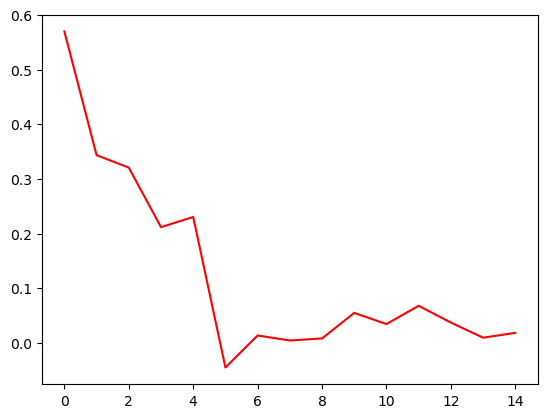

In [12]:
# calculate the mean of X for each column
means = np.mean(X, axis=0)
# plot the means as a line 
plt.plot(means[:], color='red')
# plot swam plot of the first 10 columns of X
# import seaborn as sns
# sns.swarmplot(data=X[:,:10])


In [13]:
# calculate the feature importance p-values
feature_importance_p_val_ = get_feature_importance_p_values(X, y, n_estimators=n_estimators, n_repeats=n_repeats, n_jobs=n_jobs, max_features=max_features, split=split)

The accuracy of the model is:  0.726
The accuracy of the model with permuted labels is:  0.44


In [48]:
feature_importance_p_val_.sort_values(by='p_value_oob', ascending=True).head(10)

,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted,accuracy,accuracy_permuted
0,0,0.000999,0.013487,0.173837,0.067161,0.000999,0.014486,0.373539,0.205335,0.726,0.44
1,1,0.000999,0.013487,0.087500,0.064882,0.000999,0.014486,0.153568,0.104291,0.726,0.44
4,4,0.000999,0.013487,0.107390,0.070232,0.071928,0.935065,0.091537,0.094580,0.726,0.44
3,3,0.003996,0.043956,0.080961,0.067741,0.385614,4.627373,0.073522,0.073561,0.726,0.44
2,2,0.000999,0.013487,0.082465,0.065821,0.500500,5.505495,0.119190,0.122460,0.726,0.44
7,7,1.000000,1.500000,0.044233,0.071399,0.556444,5.564436,0.019367,0.031552,0.726,0.44
12,12,0.007992,0.079920,0.051537,0.055586,0.591409,5.322677,0.018072,0.037188,0.726,0.44
5,5,0.972028,7.776224,0.047639,0.067030,0.723277,5.786214,0.024845,0.032561,0.726,0.44
9,9,1.000000,1.500000,0.043317,0.067602,0.829171,5.804196,0.020188,0.045359,0.726,0.44
10,10,0.723277,6.509491,0.048716,0.059651,0.901099,5.406593,0.021167,0.050452,0.726,0.44


In [37]:
feature_importance_p_val_.sort_values(by='feature_importance_oob', ascending=False)[:]

,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted,accuracy,accuracy_permuted
0,0,0.000999,0.013487,0.173837,0.067161,0.000999,0.014486,0.373539,0.205335,0.726,0.44
1,1,0.000999,0.013487,0.087500,0.064882,0.000999,0.014486,0.153568,0.104291,0.726,0.44
2,2,0.000999,0.013487,0.082465,0.065821,0.500500,5.505495,0.119190,0.122460,0.726,0.44
4,4,0.000999,0.013487,0.107390,0.070232,0.071928,0.935065,0.091537,0.094580,0.726,0.44
3,3,0.003996,0.043956,0.080961,0.067741,0.385614,4.627373,0.073522,0.073561,0.726,0.44
5,5,0.972028,7.776224,0.047639,0.067030,0.723277,5.786214,0.024845,0.032561,0.726,0.44
10,10,0.723277,6.509491,0.048716,0.059651,0.901099,5.406593,0.021167,0.050452,0.726,0.44
8,8,0.995005,4.975025,0.046157,0.072583,0.968032,1.936064,0.020807,0.042523,0.726,0.44
6,6,0.999001,2.997003,0.048373,0.074310,0.964036,2.892108,0.020406,0.044393,0.726,0.44
9,9,1.000000,1.500000,0.043317,0.067602,0.829171,5.804196,0.020188,0.045359,0.726,0.44


In [104]:
# define a function to save a dataframe as a csv file and append the data to the file if it exists
def save_df_as_csv(df, file_name):
    if os.path.exists(file_name):
        df.to_csv(file_name, mode='a', header=False, index=False)
    else:
        df.to_csv(file_name, mode='w', header=True, index=False)

# Question: 
1. What happens if we repeat the process with different train/test splits?
2. Is this a function of train/test split proportion?
3. Is this a function of the max_features parameter?
4. Is this a function of the performance of the model?
5. is this a function of the sample size?

In [113]:
# define a function to run the simulations
def run_simulation(n_samples, n_dim, n_informative, mu_0, mu_1, rho, band_type, scaling_factor, max_features,n_estimators,n_repeats,split, seed, n_jobs):
    X, y = make_trunk_classification(n_samples=n_samples, n_dim=n_dim, n_informative=n_informative, mu_0=mu_0, mu_1=mu_1, rho=rho, band_type=band_type, return_params=False, scaling_factor=scaling_factor, seed=seed)
    feature_importance_p_val = get_feature_importance_p_values(X, y, n_estimators=n_estimators, n_repeats=n_repeats, n_jobs=n_jobs, max_features=max_features, split=split)
    # add the parameters to the dataframe
    feature_importance_p_val['sample_size'] = n_samples
    feature_importance_p_val['n_features'] = n_dim
    feature_importance_p_val['max_features'] = max_features
    feature_importance_p_val['n_estimators'] = n_estimators
    feature_importance_p_val['n_repeats'] = n_repeats
    feature_importance_p_val['test_size'] = split[1]
    # add the mean of the features to the dataframe
    feature_importance_p_val['feature_mean'] = np.mean(X, axis=0)
    return feature_importance_p_val

# run the simulation
import pickle
n_samples = 100
n_dim = 100
n_informative = 10
mu_0 = 0
mu_1 = 1
rho = 0
band_type = 'ma'
scaling_factor = 1.0
max_features = 1/3
n_estimators = 10000
n_repeats = 10000
split = (0.8, 0.2)
seed = None
n_jobs = -5
file_name = './feature_importance_p_val_all.csv'

n_rep = 1
feature_importance_p_val = []
for i in range(n_rep):
    feature_importance_p_val_ = run_simulation(n_samples, n_dim, n_informative, mu_0, mu_1, rho, band_type, scaling_factor, max_features,n_estimators,n_repeats,split, seed, n_jobs)
    feature_importance_p_val.append(feature_importance_p_val_)
    print(f"simulation {i} completed")
    # save the results
    save_df_as_csv(feature_importance_p_val_, file_name)
    

# concatenate the results
feature_importance_p_val = pd.concat(feature_importance_p_val)
# save the results
# save_df_as_csv(feature_importance_p_val, file_name)
feature_importance_p_val.sort_values(by='feature_importance_oob', ascending=False)[:20]

The accuracy of the model is:  0.7
The accuracy of the model with permuted labels is:  0.4
simulation 0 completed


,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted,accuracy,accuracy_permuted,sample_size,n_features,max_features,n_estimators,n_repeats,test_size,feature_mean
1,1,0.000100,0.009849,0.142725,0.005626,0.000100,0.009999,0.759037,0.004816,0.7,0.4,100,100,0.333333,10000,10000,0.2,0.329162
18,18,0.409059,30.679432,0.010722,0.008422,0.998900,85.905409,0.249224,0.009767,0.7,0.4,100,100,0.333333,10000,10000,0.2,0.013170
97,97,0.998700,14.481152,0.004835,0.014145,1.000000,31.500000,0.220189,0.006545,0.7,0.4,100,100,0.333333,10000,10000,0.2,-0.009057
46,46,0.083692,7.030097,0.011765,0.006977,1.000000,31.500000,0.121170,0.001688,0.7,0.4,100,100,0.333333,10000,10000,0.2,-0.106968
32,32,0.823018,45.265973,0.006669,0.008569,1.000000,31.500000,0.120532,0.004167,0.7,0.4,100,100,0.333333,10000,10000,0.2,0.081970
9,9,0.241476,18.593641,0.014473,0.011283,0.999900,67.993201,0.094405,-0.001113,0.7,0.4,100,100,0.333333,10000,10000,0.2,0.220769
34,34,0.000200,0.019198,0.021188,0.007561,0.972903,94.371563,0.069384,0.018909,0.7,0.4,100,100,0.333333,10000,10000,0.2,-0.014898
0,0,0.070993,6.034397,0.017510,0.011313,0.991301,93.182282,0.066771,0.047858,0.7,0.4,100,100,0.333333,10000,10000,0.2,0.408944
44,44,0.000100,0.009849,0.029205,0.006469,0.941106,92.228377,0.064438,0.022434,0.7,0.4,100,100,0.333333,10000,10000,0.2,-0.078810
13,13,1.000000,3.500000,0.005490,0.016866,0.999900,67.993201,0.044167,-0.039035,0.7,0.4,100,100,0.333333,10000,10000,0.2,-0.023878


In [118]:
# list to store the results
results = []
for n_samples in [100, 1000, 10000]:
    for n_dim in [100, 1000, 10000]:
        for n_informative in [10]:
            for mu_0 in [0]:
                for mu_1 in [1]:
                    for rho in [0]:
                        for band_type in ['ma']:
                            for scaling_factor in [1.0]:
                                for max_features in [ 1/3]:
                                    for n_estimators in [100, 1000]:
                                        for n_repeats in [10000]:
                                            for split in [(0.5, 0.5), (0.8, 0.2)]:
                                                for seed in [None]:
                                                    for n_jobs in [-5]:
                                                        # print out the current parameters
                                                        print(f"running simulation for: {n_samples}, {n_dim}, {n_informative}, {mu_0}, {mu_1}, {rho}, {band_type}, {scaling_factor}, {max_features}, {n_estimators}, {n_repeats}, {split}, {seed}, {n_jobs}")
                                                        feature_importance_p_val_ = run_simulation(n_samples, n_dim, n_informative, mu_0, mu_1, rho, band_type, scaling_factor, max_features,n_estimators,n_repeats,split, seed, n_jobs)
                                                        # save the results
                                                        # append the results to the list
                                                        results.append(feature_importance_p_val_)
                                                        save_df_as_csv(feature_importance_p_val_, file_name)
                                                        print(f"simulation completed for: {n_samples}, {n_dim}, {n_informative}, {mu_0}, {mu_1}, {rho}, {band_type}, {scaling_factor}, {max_features}, {n_estimators}, {n_repeats}, {split}, {seed}, {n_jobs}")

running simulation for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.5, 0.5), None, -5
The accuracy of the model is:  0.66
The accuracy of the model with permuted labels is:  0.58


95335.84s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.84s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.84s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.85s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.86s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.87s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.88s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.88s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.88s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
95335.88s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
0.00s - Debugger warning: It seems that 

simulation completed for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.5, 0.5), None, -5
running simulation for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.8, 0.2), None, -5
The accuracy of the model is:  0.7
The accuracy of the model with permuted labels is:  0.5
simulation completed for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.8, 0.2), None, -5
running simulation for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 1000, 10000, (0.5, 0.5), None, -5
The accuracy of the model is:  0.56
The accuracy of the model with permuted labels is:  0.36
simulation completed for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 1000, 10000, (0.5, 0.5), None, -5
running simulation for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 1000, 10000, (0.8, 0.2), None, -5
The accuracy of the model is:  0.85
The accuracy of the model with permuted labels is:  0.5
simulation completed for: 100, 100, 10, 0, 1, 0, ma, 1.0, 0.3

102621.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.02s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.02s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.04s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.05s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.07s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
102621.07s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
0.00s - Debugger warning: It s

simulation completed for: 1000, 10000, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 1000, 10000, (0.8, 0.2), None, -5
running simulation for: 10000, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.5, 0.5), None, -5
The accuracy of the model is:  0.7824
The accuracy of the model with permuted labels is:  0.4752
simulation completed for: 10000, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.5, 0.5), None, -5
running simulation for: 10000, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.8, 0.2), None, -5
The accuracy of the model is:  0.784
The accuracy of the model with permuted labels is:  0.4835
simulation completed for: 10000, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.8, 0.2), None, -5
running simulation for: 10000, 100, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 1000, 10000, (0.5, 0.5), None, -5
The accuracy of the model is:  0.7806
The accuracy of the model with permuted labels is:  0.4894
simulation completed for: 10000, 10

...

105392.64s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.64s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.67s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.69s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.71s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.73s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.73s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.75s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
105392.76s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
0.00s - Debugger warning: It s

simulation completed for: 10000, 1000, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 1000, 10000, (0.8, 0.2), None, -5
running simulation for: 10000, 10000, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.5, 0.5), None, -5
The accuracy of the model is:  0.7534
The accuracy of the model with permuted labels is:  0.4898
simulation completed for: 10000, 10000, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.5, 0.5), None, -5
running simulation for: 10000, 10000, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.8, 0.2), None, -5
The accuracy of the model is:  0.7395
The accuracy of the model with permuted labels is:  0.4895


106397.65s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.65s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.65s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.65s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.71s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.72s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.73s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.75s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.81s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
106397.83s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
0.00s - Debugger warning: It s

simulation completed for: 10000, 10000, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 100, 10000, (0.8, 0.2), None, -5
running simulation for: 10000, 10000, 10, 0, 1, 0, ma, 1.0, 0.3333333333333333, 1000, 10000, (0.5, 0.5), None, -5
The accuracy of the model is:  0.745


KeyboardInterrupt: 

In [121]:
pd.read_csv("feature_importance_p_val_all.csv")

,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted,accuracy,accuracy_permuted,sample_size,n_features,max_features,n_estimators,n_repeats,test_size,feature_mean
0,0,0.000100,0.029547,0.151282,0.003280,0.0001,0.015198,0.390421,0.012941,0.7060,0.5040,1000,300,0.3333333333333333,10000,10000,0.5,0.532979
1,1,0.000100,0.029547,0.048699,0.005377,0.0001,0.015198,0.158760,0.025176,0.7060,0.5040,1000,300,0.3333333333333333,10000,10000,0.5,0.394222
2,2,0.000100,0.029547,0.025726,0.002911,0.0001,0.015198,0.067434,0.009352,0.7060,0.5040,1000,300,0.3333333333333333,10000,10000,0.5,0.311025
3,3,0.000100,0.029547,0.023062,0.002749,0.0001,0.015198,0.043824,0.008051,0.7060,0.5040,1000,300,0.3333333333333333,10000,10000,0.5,0.323411
4,4,0.000100,0.029547,0.019742,0.002816,0.0001,0.015198,0.022900,0.005138,0.7060,0.5040,1000,300,0.3333333333333333,10000,10000,0.5,0.230624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114595,9995,0.649635,3877.021898,0.000028,0.000046,0.0001,0.500300,0.000061,-0.000059,0.7395,0.4895,10000,10000,0.333333,100,10000,0.2,0.001831
114596,9996,0.761924,3710.568943,0.000100,0.000097,0.0001,0.500300,0.000011,0.000095,0.7395,0.4895,10000,10000,0.333333,100,10000,0.2,-0.007454
114597,9997,0.804720,3585.025497,0.000014,0.000097,0.0001,0.500300,0.000031,-0.000121,0.7395,0.4895,10000,10000,0.333333,100,10000,0.2,0.000138
114598,9998,0.888611,2756.027447,0.000032,0.000064,0.0001,0.500300,-0.000009,0.000174,0.7395,0.4895,10000,10000,0.333333,100,10000,0.2,-0.025949


In [112]:
# # concatenate feature_importance_p_val_list into a dataframe
# feature_importance_p_val_all = pd.concat(feature_importance_p_val_list, axis=0)
# display the first 10 rows
feature_importance_p_val.sort_values(by='p_value_oob_adjusted', ascending=True)[:20]

,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted,accuracy,accuracy_permuted,sample_size,n_features,max_features,n_estimators,n_repeats,test_size,feature_mean
0,0,0.000100,0.009599,0.127785,0.009144,0.000100,0.009649,0.491742,0.036289,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.542822
1,1,0.000100,0.009599,0.081342,0.009520,0.000100,0.009649,0.117513,0.021320,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.326303
2,2,0.000100,0.009599,0.054433,0.014920,0.000100,0.009649,0.180372,0.064022,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.245281
3,3,0.000100,0.009599,0.037344,0.010269,0.000100,0.009649,0.039028,0.014263,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.221603
4,4,0.000100,0.009599,0.031868,0.009739,0.000100,0.009649,0.041629,0.016160,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.198683
5,5,0.000100,0.009599,0.021436,0.008714,0.000100,0.009649,0.026354,0.012422,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.233199
6,6,0.000100,0.009599,0.015175,0.008949,0.000100,0.009649,0.015732,0.011689,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.211343
8,8,0.000100,0.009599,0.022065,0.012012,0.000100,0.009649,0.028107,0.020254,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.145362
7,7,0.000100,0.009599,0.014968,0.009430,0.000700,0.064394,0.015793,0.013349,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.219892
80,80,0.999000,36.963004,0.007065,0.010994,1.000000,4.500000,-0.001211,0.011110,0.83,0.535,1000,100,0.333333,10000,10000,0.2,0.034417


In [ ]:
# 2. run the above with different split
splits = [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2), (0.9, 0.1)]
feature_importance_p_val_list = []

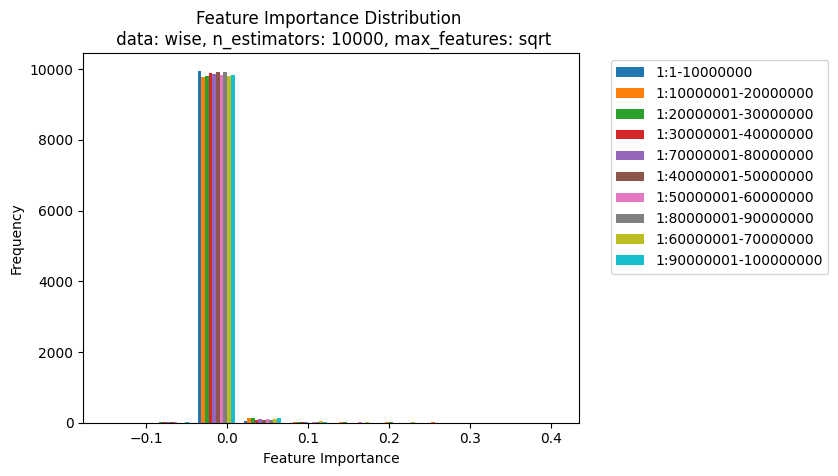

In [86]:
idx = feature_importance_p_val.sort_values(by='feature_importance_oob', ascending=False)[:10].index
plt.hist(np.array(oob_sample_feature_importance)[:, idx])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 156])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 154])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 152])
plt.xlabel('Feature Importance')
plt.ylabel('Frequency')
plt.title(f'Feature Importance Distribution \n data: {dataset}, n_estimators: {n_estimators}, max_features: {max_features}')
# move the legend outside the plot
plt.legend(X_train.columns[idx], bbox_to_anchor=(1.05, 1), loc='upper left')


,feature,p_value_ib,p_value_ib_adjusted,feature_importance_ib,feature_importance_ib_permuted,p_value_oob,p_value_oob_adjusted,feature_importance_oob,feature_importance_oob_permuted
0,1:1-10000000,1.0000,98.000000,0.000604,0.005498,1.0,150.5,0.000099,0.001612
203,12:20000001-30000000,1.0000,98.000000,0.001153,0.003418,1.0,150.5,0.000692,0.013733
202,12:10000001-20000000,1.0000,98.000000,0.000996,0.004405,1.0,150.5,0.001018,0.041602
201,12:1-10000000,0.9994,214.871013,0.001408,0.002632,1.0,150.5,0.001166,0.003410
200,11:130000001-140000000,1.0000,98.000000,0.001076,0.007591,1.0,150.5,0.000221,0.008822
199,11:120000001-130000000,1.0000,98.000000,0.000524,0.003050,1.0,150.5,0.000106,0.000994
198,11:110000001-120000000,1.0000,98.000000,0.000542,0.002349,1.0,150.5,-0.000002,-0.000055
204,12:30000001-40000000,1.0000,98.000000,0.000984,0.004209,1.0,150.5,0.000529,0.015900
197,11:100000001-110000000,1.0000,98.000000,0.000761,0.003283,1.0,150.5,0.000050,0.000243
195,11:80000001-90000000,1.0000,98.000000,0.000730,0.005256,1.0,150.5,0.000237,0.009757


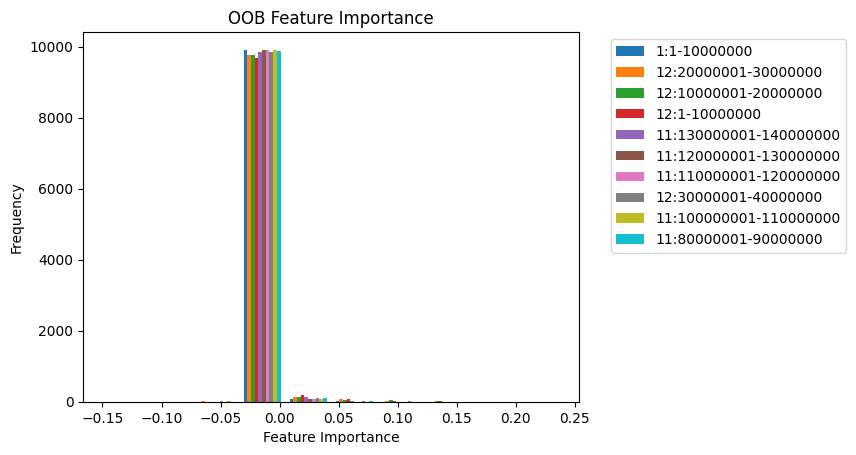

In [37]:
display(feature_importance_p_val.sort_values(by='p_value_oob_adjusted', ascending=True)[:10])
idx = feature_importance_p_val.sort_values(by='p_value_oob_adjusted', ascending=True)[:10].index
plt.hist(np.array(oob_sample_feature_importance)[:, idx])
# # plt.hist(np.array(in_bag_sample_feature_imptance)[:, 156])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 154])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 152])
plt.xlabel('Feature Importance')
plt.ylabel('Frequency')
plt.title('OOB Feature Importance')
# move the legend outside the plot
plt.legend(X_train.columns[idx], bbox_to_anchor=(1.05, 1), loc='upper left')

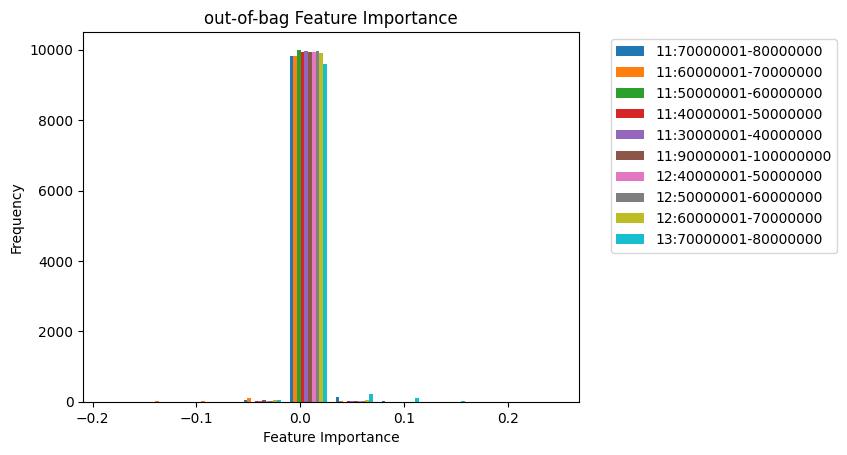

In [38]:
idx = feature_importance_p_val.sort_values(by='p_value_oob', ascending=True)[10:20].index
plt.hist(np.array(oob_sample_feature_importance)[:, idx])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 156])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 154])
# # plt.hist(np.array(in_bag_sample_feature_importance)[:, 152])
plt.xlabel('Feature Importance')
plt.ylabel('Frequency')
plt.title('out-of-bag Feature Importance')
# move the legend outside the plot
plt.legend(X_train.columns[idx], bbox_to_anchor=(1.05, 1), loc='upper left')